In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
from pathlib import Path
import missingno as msno

In [24]:
TITANIC_DATA_PATH   = Path('../practice/datasets/kaggle/titanic/train.csv')
TITANIC_MODEL_DIR   = Path('../practice/models/titanic'); TITANIC_MODEL_DIR.mkdir(exist_ok=True)
TITANIC_OUTPUT_DIR  = Path('../practice/outputs/titanic'); TITANIC_OUTPUT_DIR.mkdir(exist_ok=True)

In [26]:
titanic_df=pd.read_csv(TITANIC_DATA_PATH)

In [27]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
titanic_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [29]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [36]:
titanic_df.dropna().describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,455.366120,0.672131,1.191257,35.674426,0.464481,0.475410,78.682469
std,247.052476,0.470725,0.515187,15.643866,0.644159,0.754617,76.347843
min,2.000000,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,263.500000,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,457.000000,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,676.000000,1.000000,1.000000,47.500000,1.000000,1.000000,90.000000
max,890.000000,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


In [30]:
titanic_stats=titanic_df.describe()

In [34]:
titanic_stats.loc['range']=titanic_stats.loc['max']-titanic_stats.loc['min']
titanic_stats.loc['iqr']=titanic_stats.loc['75%']-titanic_stats.loc['25%']
titanic_stats.loc['cv']=titanic_stats.loc['std']/titanic_stats.loc['mean']
titanic_stats.loc['skew_signal']=titanic_stats.loc['mean']-titanic_stats.loc['50%'] # mean -median
titanic_stats.loc['lower_bound']=titanic_stats.loc['25%']-(1.5 * titanic_stats.loc['iqr'])
titanic_stats.loc['upper_bound']=titanic_stats.loc['75%']+(1.5 * titanic_stats.loc['iqr'])
titanic_stats.loc['extreme_lower_bound']=titanic_stats.loc['25%']-(3 * titanic_stats.loc['iqr'])
titanic_stats.loc['extreme_upper_bound']=titanic_stats.loc['75%']+(3 * titanic_stats.loc['iqr'])

In [37]:
titanic_stats

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200
range,890.000000,1.000000,2.000000,79.580000,8.000000,6.000000,512.329200
iqr,445.000000,1.000000,1.000000,17.875000,1.000000,0.000000,23.089600



#### Note:
<div>

Lower bound=Q1−1.5×IQR

Upper bound=Q3+1.5×IQR

👉 Any value outside this range = potential anomaly.

            Q1−3×IQR,Q3+3×IQR

👉 These are strong anomalies / data errors

From describe():

mean

50% (median)

Rule:

mean ≈ median → symmetric distribution

mean >> median → right skew (possible high outliers)

mean << median → left skew (possible low outliers)

👉 Large difference = possible anomalies or skewed distribution

</div>

In [ ]:
#correlation matrix will specifies how th columns are related to each other. we will visit this latter
titanic_df.select_dtypes(["integer"]).corr()

,PassengerId,Survived,Pclass,SibSp,Parch
PassengerId,1.000000,-0.005007,-0.035144,-0.057527,-0.001652
Survived,-0.005007,1.000000,-0.338481,-0.035322,0.081629
Pclass,-0.035144,-0.338481,1.000000,0.083081,0.018443
SibSp,-0.057527,-0.035322,0.083081,1.000000,0.414838
Parch,-0.001652,0.081629,0.018443,0.414838,1.000000


### <span style="center">Detecting missing values and profiling</span>

In [48]:
missing_df=pd.DataFrame({"count":titanic_df.isna().sum(),
                         "pct":titanic_df.isna().mean().mul(100).round(2)})
missing_df

,count,pct
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [ ]:
# missing-ness correlation helps to identify MAR
missing_matrix=titanic_df.isna().astype(int)
missing_matrix

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,0,0,0,0,0,0,0,0,1,0
887,0,0,0,0,0,0,0,0,0,0,0,0
888,0,0,0,0,0,1,0,0,0,0,1,0
889,0,0,0,0,0,0,0,0,0,0,0,0


<Axes: >

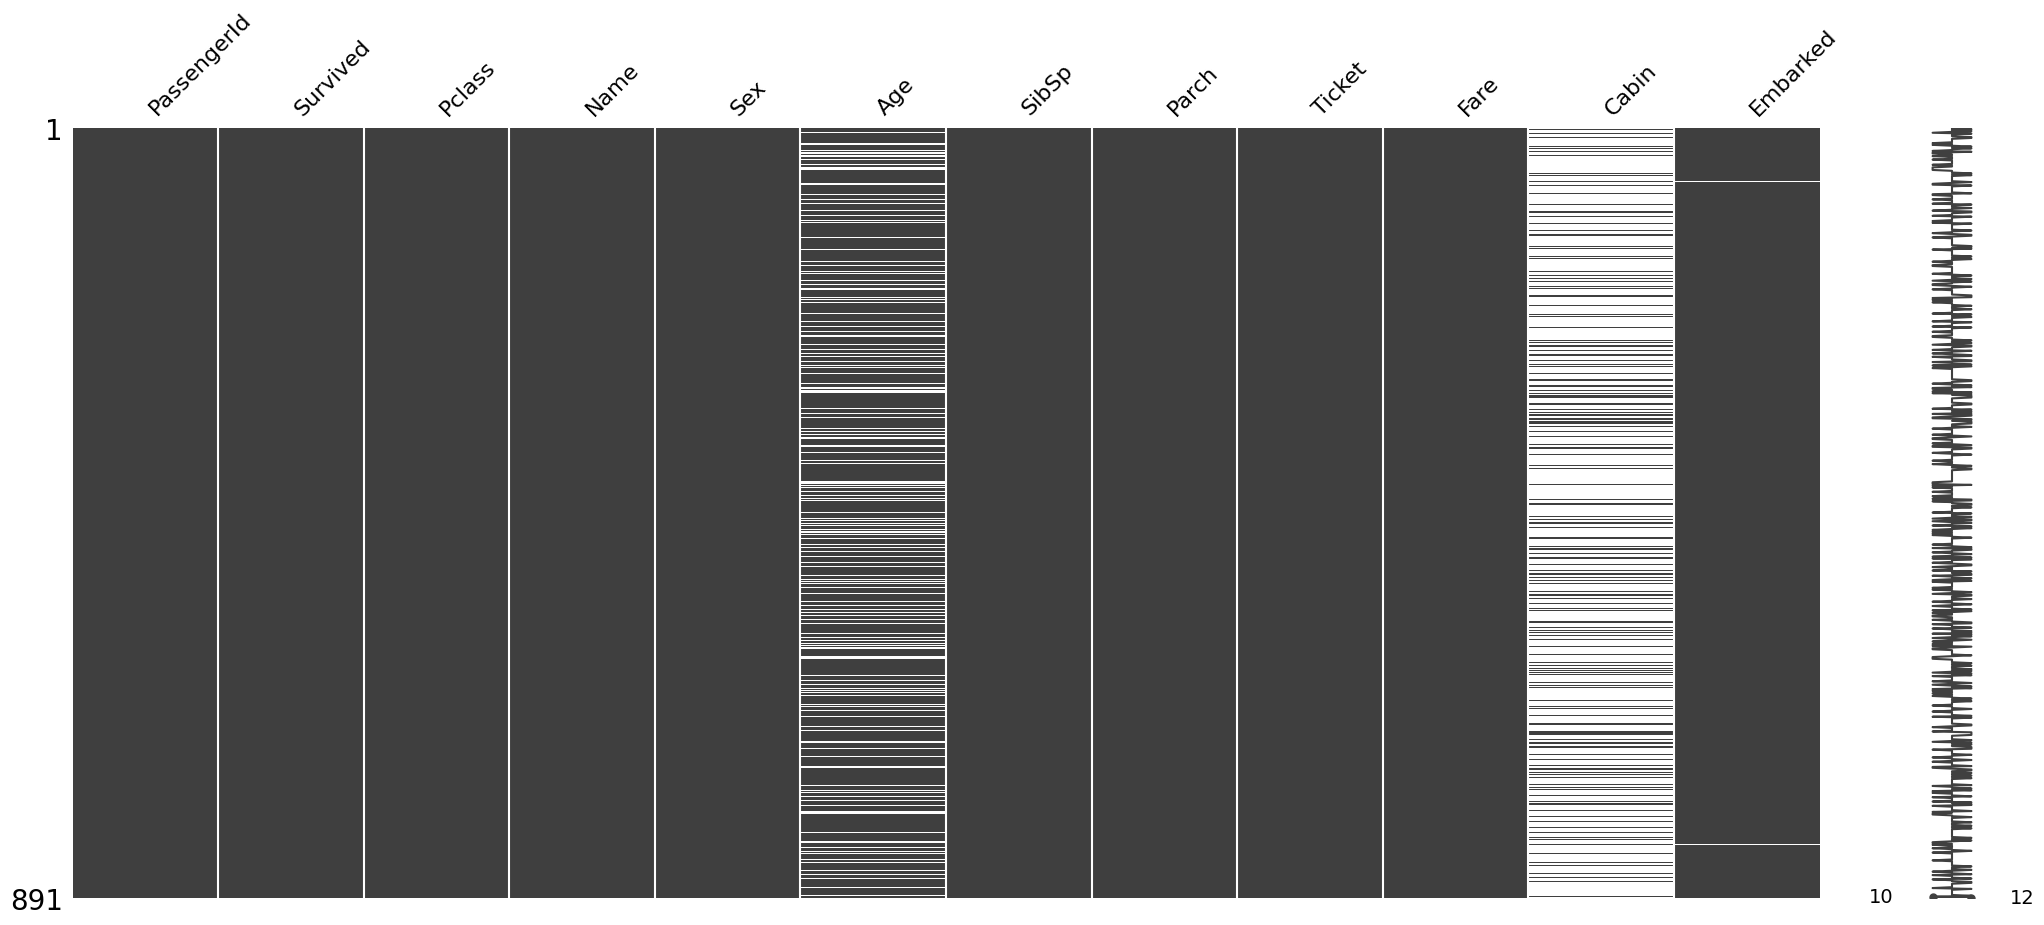

In [50]:
msno.matrix(titanic_df)

<Axes: >

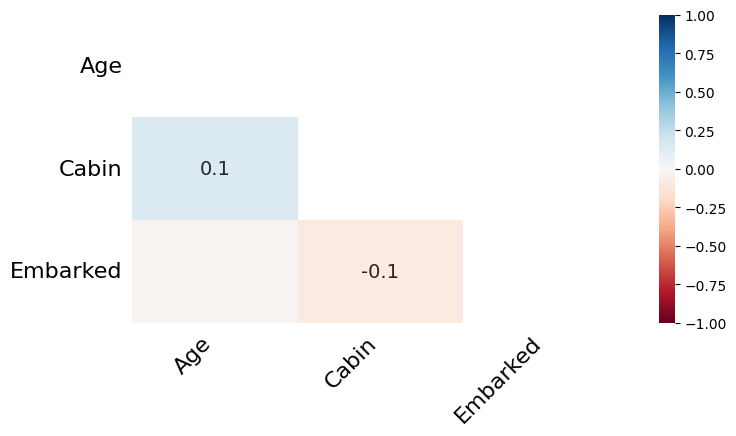

In [51]:
msno.heatmap(titanic_df,figsize=(8, 4))

###        <center> <font color='#FF5733'> Generic overview of missing fields handling as a part of data cleaning and EDA </font> </center>



<div align="center">
    <img src="/Users/lakshmikalyani/claude-prep-ml/prep/practice/images/missing-values/missing-values-overview.png" width="700">
</div>

<div style="text-align: left;">

#### <font color='#FF5733'>Following are different stages of handling missing values</font>

##### 1. Understanding the types of missingness
##### 2. Detection and profiling
##### 3. Techniques from basic to advanced 
   
            a. Deletion(baseline)
            b. Statistical imputation
            c. KNN imputation
            d. Iterative / matrix imputation (MICE-style)
            e. Missingness indicators (for MNAR)
            f. Tree models + native NaN handling

##### 4. Production-standard pipeline
##### 5. Runtime missing-value monitoring
<div>

<div style="border: 1px solid black; text-align: left; font-weight: bold; padding: 5px;">
Decision guide


| Scenario | Recommended technique |
| :--- | :--- |
| *MCAR, <5% missing* | Listwise deletion or median impute |
| *MAR, numeric* | KNN or IterativeImputer |
| *MAR, many cols* | IterativeImputer with RF estimator |
| *MNAR* | Missingness indicator + any imputer |
| *Tabular + tree model* | LightGBM / XGBoost native NaN |
| *Production serving* | Sklearn Pipeline with joblib |
| *Monitoring* | Per-column rate drift alerts |

</div>


<font color='#a7093de1'>some situations will drive us to choose mean/median/mode, how to decide which one to choose and how to impute them</font>

<div align="center">
    <img src="/Users/lakshmikalyani/claude-prep-ml/prep/practice/images/missing-values/mean_median_mode_selection.png" width="600">
</div>

##### The core rule in one sentence
Mean = use when data is numeric and symmetric (bell-shaped). 

Median = use when numeric but skewed or has outliers. 

Mode = use for categorical (or heavily discrete) columns.


### Before Handling missing values we will see some samples to understand the nature of the data 

In [1]:
import numpy as np
import pandas as pd

In [3]:
salaries = [30000, 32000, 35000, 31000, 33000, 500000]
print(f"mean {np.mean(salaries):,.0f}") # --- one person salary 500000 took away the mean
print(f"median {np.median(salaries):,.0f}") # <-- 


mean 110,167
median 32,500


In [ ]:
import pandas as pd
import numpy as np

def recommend_strategy(series: pd.Series) -> str:
    """Recommend mean / median / mode for a single column."""
    if series.dtype == "object" or series.nunique() < 10:
        return "mode"
    
    skewness = series.skew()
    
    # IQR-based outlier check
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    has_outliers = ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).any()
    
    if abs(skewness) > 0.5 or has_outliers:
        return "median"
    else:
        return "mean"

# Run on every column
df = pd.DataFrame({
    "height":   [170, 172, np.nan, 168, 175, 171,186],
    "income":   [30000, 32000, np.nan, 31000, 500000, 33000,34000],
    "city":     ["NYC", "LA", np.nan, "NYC", "Chicago", "LA","Dallas"],
    "age":      [25, 30, np.nan, 28, 35, 27,31],
})

for col in df.columns:
    strategy = recommend_strategy(df[col].dropna())
    print(f"{col:12s} → {strategy}")



height       → median
income       → median
city         → mode
age          → median


In [18]:
# Little more cleaner code

import pandas as pd
import numpy as np

class ImputationStrategy:
    @staticmethod
    def recommend(series: pd.Series, skew_threshold: float = 1.0) -> str:
        """
        Implements the missing column decision flowchart.
        """
        # 1. What data type?
        if series.dtype == "object" or series.dtype.name == "category":
            return "MODE"

        # 2. Outliers present? (Using 1.5 * IQR rule)
        q1, q3 = series.quantile([0.25, 0.75])
        iqr = q3 - q1
        has_outliers = ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).any()

        if has_outliers:
            return "MEDIAN"

        # 3. Distribution skewed?
        if abs(series.skew()) > skew_threshold:
            return "MEDIAN"

        # 4. Default to Mean (Symmetric, no outliers)
        return "MEAN"

# --- Testing with your example ---
df = pd.DataFrame({
    "height": [170, 172, 168, 175, 171],      # Normal-ish
    "income": [30000, 32000, 31000, 500000, 33000],    # Outlier (500k)
    "city":   ["NYC", "LA", "NYC", "CHI", "LA"], # Categorical
    "age":    [25, 30, 28, 35, 27],           # Slight skew
})

for col in df.columns:
    # We dropna() just for the calculation as per the flowchart logic
    strategy = ImputationStrategy.recommend(df[col].dropna())
    print(f"{col:10s} Strategy: {strategy}")


height     Strategy: MEAN
income     Strategy: MEDIAN
city       Strategy: MODE
age        Strategy: MEDIAN


## Implementing all three cleanly


In [61]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# -- step 1 : Categorize columns
def split_columns(df: pd.DataFrame):
    mean_cols, median_cols, mode_cols = [], [], []
    for col in df.columns:
        s = df[col].dropna()
        if s.dtype == "object" or s.nunique() < 10:
            mode_cols.append(col)
            continue
        skewed    = abs(s.skew()) > 0.5
        q1, q3    = s.quantile(0.25), s.quantile(0.75)
        outliers  = ((s < q1 - 1.5*(q3-q1)) | (s > q3 + 1.5*(q3-q1))).any()
        if skewed or outliers:
            median_cols.append(col)
        else:
            mean_cols.append(col)
    return mean_cols, median_cols, mode_cols




In [63]:
from sklearn.model_selection import (train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve)
SEED=42
X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
mean_cols, median_cols, mode_cols = split_columns(X_train)


preprocessor = ColumnTransformer([
    ("mean_imp",   SimpleImputer(strategy="mean"),         mean_cols),
    ("median_imp", SimpleImputer(strategy="median"),       median_cols),
    ("mode_imp",   SimpleImputer(strategy="most_frequent"),mode_cols),
], remainder="passthrough")

X_train_imp = preprocessor.fit_transform(X_train)
X_test_imp  = preprocessor.transform(X_test) 

### Quick reference table


| Situation | Use | Why |
| :--- | :--- | :--- |
| Symmetric numeric (height, temp) | **Mean** | Minimises squared error, uses all signal |
| Skewed numeric (income, price) | **Median** | Robust to outliers, represents the middle person |
| Numeric with known outliers | **Median** | Outliers distort the mean heavily |
| Categorical (city, color, type) | **Mode** | Only option that produces a valid category |
| Low-cardinality integer (rating 1-5) | **Mode** | Keeps values interpretable |
| Time-series / ordered data | Neither — use forward-fill | Temporal context matters more than central tendency |


### some times we may get categorical data in the form of integer in a columns in such a scenario, any bins/buckets any such kind of situation how to impute values and deal with missing

<div align="center">
    <img src="/Users/lakshmikalyani/claude-prep-ml/prep/practice/images/missing-values/missing-values-with-edge-cases.png" width="600">
</div>

### The four scenarios in detail

*   **Scenario 1 — Nominal integer (labels encoded as numbers)**
    The integers have no meaningful order. Region codes like 0=North, 1=South, 2=East are not "less than" each other. Mean/median of [0, 1, 2] = 1.0 (East?) — that's meaningless.
*   **Scenario 2 — Ordinal integer (order matters, scale is meaningful)**
    Ratings like 1–5 stars have order. You can use mode (safest) or median (acceptable). Mean is risky — imputing 3.4 stars when only 1,2,3,4,5 are valid breaks the scale.
*   **Scenario 3 — Binned / bucketed column (the trickiest)**
    You have age_group = [0, 1, 2, 3, 4] where 0=<18, 1=18–30, 2=31–45, 3=46–60, 4=60+. Two approaches depending on whether you still have the raw column.
*   **Scenario 4 — Mixed column (could be either)**
    Sometimes you don't know the column's intent. Use this automated detector before imputing:


**Scenario 1 — Nominal integer (labels encoded as numbers)**

In [74]:
df = pd.DataFrame({
    "region": [0, 1, np.nan, 2, 0, np.nan, 1],   # 0=North, 1=South, 2=East
    "score":  [85, 90, 78, np.nan, 92, 88, 76]
})
# Cast to string/category FIRST so sklearn treats it as categorical
df["region"] = df["region"].astype("Int64").astype(str)   # "0","1","2", "<NA>"
cat_imp = SimpleImputer(strategy="most_frequent",missing_values="<NA>")
df["region"] = cat_imp.fit_transform(df[["region"]]).ravel()

# Cast back to int after imputing if downstream code needs int
df["region"] = df["region"].astype(int)
print(df["region"].value_counts())
df

region
0    4
1    2
2    1
Name: count, dtype: int64


,region,score
0,0,85.0
1,1,90.0
2,0,78.0
3,2,NaN
4,0,92.0
5,0,88.0
6,1,76.0


Key step: convert to str before imputing so SimpleImputer never computes arithmetic on the codes.

**Scenario 2 — Ordinal integer (order matters, scale is meaningful)**

In [75]:
df = pd.DataFrame({
    "rating": [1, 5, 3, np.nan, 4, 2, np.nan, 5, 3]
})

# Option A — mode (most common valid value)
mode_val = int(df["rating"].mode()[0])
df["rating_mode"] = df["rating"].fillna(mode_val)

# Option B — median rounded to nearest valid integer
median_val = int(round(df["rating"].median()))
df["rating_median"] = df["rating"].fillna(median_val)

# Option C — sklearn pipeline way
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy="most_frequent")
df["rating_imp"] = imp.fit_transform(df[["rating"]]).ravel().astype(int)

print(df)

   rating  rating_mode  rating_median  rating_imp
0     1.0          1.0            1.0           1
1     5.0          5.0            5.0           5
2     3.0          3.0            3.0           3
3     NaN          3.0            3.0           3
4     4.0          4.0            4.0           4
5     2.0          2.0            2.0           2
6     NaN          3.0            3.0           3
7     5.0          5.0            5.0           5
8     3.0          3.0            3.0           3


Rule: always cast back to int after imputing ordinal — a 3.0 float sneaking into a 1–5 rating column causes silent bugs downstream.


**Scenario 3 — Binned / bucketed column (the trickiest)**


You have age_group = [0, 1, 2, 3, 4] where 0=<18, 1=18–30, 2=31–45, 3=46–60, 4=60+. Two approaches depending on whether you still have the raw column.

In [76]:
df = pd.DataFrame({
    "age":       [25, np.nan, 52, 17, np.nan, 38, 61, 29],
    "age_group": [1,  np.nan, 3,  0,  np.nan, 2,  4,  1 ]
})

# ── Approach A: re-derive from raw age ──────────────────────────────
# First impute raw age (median — it's numeric and skewed)
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)

# Re-bin from the now-complete raw column
bins   = [0, 18, 30, 45, 60, 120]
labels = [0,  1,  2,  3,  4]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False).astype(int)

print(df)

    age  age_group
0  25.0          1
1  33.5          2
2  52.0          3
3  17.0          0
4  33.5          2
5  38.0          2
6  61.0          4
7  29.0          1


In [77]:
df = pd.DataFrame({
    "age":       [25, np.nan, 52, 17, np.nan, 38, 61, 29],
    "age_group": [1,  np.nan, 3,  0,  np.nan, 2,  4,  1 ]
})

# ── Approach A: re-derive from raw age ──────────────────────────────
# First impute raw age (median — it's numeric and skewed)
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)

# Re-bin from the now-complete raw column
bins   = [0, 18, 30, 45, 60, 120]
labels = [0,  1,  2,  3,  4]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False).astype(int)

print(df)

    age  age_group
0  25.0          1
1  33.5          2
2  52.0          3
3  17.0          0
4  33.5          2
5  38.0          2
6  61.0          4
7  29.0          1


In [78]:
# ── Approach B: raw age unavailable — impute the bin with mode ──────
mode_bin = int(df["age_group"].mode()[0])
df["age_group"] = df["age_group"].fillna(mode_bin).astype(int)

# Optionally add a missingness indicator so the model knows it was imputed
df["age_group__was_missing"] = df["age_group"].isna().astype(int)

In [79]:
df["age_group"]

0    1
1    2
2    3
3    0
4    2
5    2
6    4
7    1
Name: age_group, dtype: int64

**Scenario 4 — Mixed column (could be either)**

Sometimes you don't know the column's intent. Use this automated detector before imputing:


In [80]:
def detect_integer_column_type(series: pd.Series) -> str:
    """
    Returns: 'nominal', 'ordinal', 'binned', or 'true_numeric'
    """
    s = series.dropna()
    
    # Non-integer values → true numeric
    if not all(s == s.astype(int)):
        return "true_numeric"
    
    n_unique   = s.nunique()
    value_range = s.max() - s.min()
    
    # Very low cardinality + values are consecutive small ints → likely encoded category
    if n_unique <= 5 and value_range == n_unique - 1 and s.min() == 0:
        return "nominal"   # 0,1,2,3 with nothing in between
    
    # Small cardinality, values start at 1 (like 1–5 ratings)
    if n_unique <= 10 and s.min() >= 1 and value_range < 20:
        return "ordinal"
    
    # Cardinality is low relative to range (suggests bins, not raw counts)
    if n_unique <= 15 and value_range > 20:
        return "binned"
    
    return "true_numeric"


# Example
import pandas as pd, numpy as np
test_cols = {
    "region":    pd.Series([0,1,2,3,0,1,2]),
    "rating":    pd.Series([1,2,3,4,5,3,4]),
    "age_group": pd.Series([0,1,2,3,4,2,3]),
    "num_items": pd.Series([0,5,12,89,34,7,110]),
}
for name, col in test_cols.items():
    print(f"{name:12s} → {detect_integer_column_type(col)}")

# region       → nominal
# rating       → ordinal
# age_group    → binned
# num_items    → true_numeric

region       → nominal
rating       → ordinal
age_group    → nominal
num_items    → binned


### Production-grade pipeline combining all cases


In [86]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ─────────────────────────────────────────────
# 1.  Sample dataset
# ─────────────────────────────────────────────
np.random.seed(42)
n = 500

df = pd.DataFrame({
    # True numeric
    "age":        np.random.randint(18, 70, n).astype(float),
    "income":     np.random.normal(50000, 15000, n),
    "score":      np.random.uniform(0, 100, n),

    # Ordinal (small int range → ranked meaning)
    "education":  np.random.randint(1, 6, n).astype(float),    # 1-5 levels
    "rating":     np.random.randint(1, 11, n).astype(float),   # 1-10 scale

    # Nominal (int codes with no order)
    "region":     np.random.randint(1, 6, n).astype(float),    # 1-5 regions
    "product_id": np.random.randint(100, 110, n).astype(float),

    # Target
    "purchased":  np.random.randint(0, 2, n),
})

# Inject ~10% missings
for col in df.columns[:-1]:
    mask = np.random.rand(n) < 0.10
    df.loc[mask, col] = np.nan

# ─────────────────────────────────────────────
# 2.  detect_integer_column_type
# ─────────────────────────────────────────────
def detect_integer_column_type(series: pd.Series) -> str:
    """
    Heuristic rules applied to a *non-null* numeric Series.
    Returns one of: 'nominal' | 'ordinal' | 'binned' | 'numeric'
    """
    s = series.dropna()

    # Must look integer-ish
    if not np.allclose(s, s.round(), equal_nan=True):
        return "numeric"

    n_unique  = s.nunique()
    val_range = s.max() - s.min()

    if n_unique <= 2:
        return "nominal"          # binary flag

    if n_unique <= 15:
        consecutive = (val_range == n_unique - 1)
        low_start   = s.min() in (0, 1)
        if consecutive and low_start:
            return "ordinal"
        return "nominal"          # non-consecutive or high-start codes

    if n_unique <= 50 and val_range <= 100:
        return "binned"

    return "numeric"

# ─────────────────────────────────────────────
# 3.  Train / test split
# ─────────────────────────────────────────────
X = df.drop(columns="purchased")
y = df["purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─────────────────────────────────────────────
# 4.  Column classification
# ─────────────────────────────────────────────
def classify_columns(df: pd.DataFrame):
    nominal, ordinal, true_num = [], [], []
    for col in df.select_dtypes(include="number").columns:
        t = detect_integer_column_type(df[col].dropna())
        if t == "nominal":
            nominal.append(col)
        elif t in ("ordinal", "binned"):
            ordinal.append(col)
        else:
            true_num.append(col)
    return nominal, ordinal, true_num

nominal_cols, ordinal_cols, numeric_cols = classify_columns(X_train)

print("Nominal :", nominal_cols)
print("Ordinal :", ordinal_cols)
print("Numeric :", numeric_cols)

# ─────────────────────────────────────────────
# 5.  Safe int → str cast  (THE FIX)
# ─────────────────────────────────────────────
def safe_int_to_str(series: pd.Series) -> pd.Series:
    """
    Cast integer codes to string while preserving NaN as actual NaN.
    Avoids the '<NA>' string bug that breaks SimpleImputer.
    """
    return series.apply(lambda x: str(int(x)) if pd.notna(x) else np.nan)

for col in nominal_cols:
    X_train[col] = safe_int_to_str(X_train[col])
    X_test[col]  = safe_int_to_str(X_test[col])

# ─────────────────────────────────────────────
# 6.  Preprocessor + Pipeline
# ─────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ("nominal", SimpleImputer(strategy="most_frequent"), nominal_cols),
    ("ordinal", SimpleImputer(strategy="most_frequent"), ordinal_cols),
    ("numeric", SimpleImputer(strategy="median"),        numeric_cols),
], remainder="passthrough")

pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", GradientBoostingClassifier(random_state=42)),
])

# ─────────────────────────────────────────────
# 7.  Fit & evaluate
# ─────────────────────────────────────────────
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Nominal : ['product_id']
Ordinal : ['education', 'rating', 'region']
Numeric : ['age', 'income', 'score']

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.53      0.52        53
           1       0.46      0.45      0.45        47

    accuracy                           0.49       100
   macro avg       0.49      0.49      0.49       100
weighted avg       0.49      0.49      0.49       100



### Summary decision table


| Column type | Example | Missing strategy | Cast after? |
| :--- | :--- | :--- | :--- |
| Nominal integer | region 0/1/2 | **Mode (treat as string)** | Back to int |
| Ordinal integer | rating 1–5 | **Mode or median &rarr; round** | Back to int |
| Binned integer | age_group 0–4 | Re-derive from raw, else mode | Back to int |
| True integer count | num_orders | **Median or mean** | Round if needed |
| True integer (normal dist) | height_cm | **Mean** | Round if needed |


## The automatic imputation engine

In [87]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion
from sklearn.ensemble import RandomForestRegressor
import joblib
from dataclasses import dataclass, field
from typing import Literal

# ── Column profile ───────────────────────────────────────────────────
@dataclass
class ColProfile:
    name: str
    dtype: str
    n_missing: int
    pct_missing: float
    n_unique: int
    skewness: float
    has_outliers: bool
    col_type: Literal["nominal","ordinal","binned","numeric","timeseries"]
    strategy: Literal["mean","median","mode","constant","knn","iterative","ffill","indicator+median"]

def _has_outliers(s: pd.Series) -> bool:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return bool(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).any())

def _detect_type(s: pd.Series) -> str:
    if s.dtype == "object" or s.dtype.name == "category":
        return "nominal"
    if pd.api.types.is_datetime64_any_dtype(s):
        return "timeseries"
    # integer-like with low cardinality
    vals = s.dropna()
    if (vals == vals.astype(int)).all() and vals.nunique() <= 15:
        if vals.min() == 0 and vals.max() == vals.nunique() - 1:
            return "nominal"       # 0,1,2,3 consecutive from 0
        if vals.min() >= 1 and vals.max() <= 10:
            return "ordinal"       # 1–5 ratings etc.
        return "binned"            # 0,1,2,3,4 but range suggests buckets
    return "numeric"

def _choose_strategy(profile: ColProfile, mnar_cols: list[str]) -> str:
    if profile.pct_missing > 0.6:
        return "constant"          # >60% missing — imputing is guessing
    if profile.col_type in ("nominal",):
        return "mode"
    if profile.col_type in ("ordinal", "binned"):
        return "mode"
    if profile.col_type == "timeseries":
        return "ffill"
    if profile.name in mnar_cols:
        return "indicator+median"
    if profile.has_outliers or abs(profile.skewness) > 0.5:
        return "median"
    return "mean"

def profile_dataframe(df: pd.DataFrame,
                      mnar_cols: list[str] = None) -> list[ColProfile]:
    mnar_cols = mnar_cols or []
    profiles = []
    for col in df.columns:
        s = df[col]
        s_clean = s.dropna()
        dtype   = str(s.dtype)
        col_type = _detect_type(s_clean) if len(s_clean) > 0 else "nominal"
        skewness = float(s_clean.skew()) if col_type == "numeric" else 0.0
        outliers = _has_outliers(s_clean) if col_type == "numeric" else False
        p = ColProfile(
            name=col, dtype=dtype,
            n_missing=int(s.isna().sum()),
            pct_missing=float(s.isna().mean()),
            n_unique=int(s.nunique()),
            skewness=skewness,
            has_outliers=outliers,
            col_type=col_type,
            strategy=""
        )
        p.strategy = _choose_strategy(p, mnar_cols)
        profiles.append(p)
    return [p for p in profiles if p.n_missing > 0]

In [91]:
# ── Auto imputer class ───────────────────────────────────────────────
class AutoImputer:
    """
    Fits once on train, transforms any split.
    Handles mean / median / mode / constant / KNN / iterative / ffill /
    indicator+median — all decided automatically from column profiles.
    """

    def __init__(self,
                 mnar_cols: list[str] = None,
                 knn_threshold: int = 50_000,
                 iterative_threshold: int = 200_000,
                 constant_cat: str = "MISSING",
                 constant_num: float = -1.0):
        self.mnar_cols            = mnar_cols or []
        self.knn_threshold        = knn_threshold
        self.iterative_threshold  = iterative_threshold
        self.constant_cat         = constant_cat
        self.constant_num         = constant_num
        self.profiles_: list[ColProfile] = []
        self._imputers: dict = {}
        self._scalers: dict  = {}
        self._indicator_cols: list[str] = []
        self._fitted_medians: dict = {}

    def fit(self, df: pd.DataFrame) -> "AutoImputer":
        n_rows = len(df)
        self.profiles_ = profile_dataframe(df, self.mnar_cols)

        # Override KNN/iterative if dataset is large
        for p in self.profiles_:
            if p.strategy == "knn" and n_rows > self.knn_threshold:
                p.strategy = "median"
            if p.strategy == "iterative" and n_rows > self.iterative_threshold:
                p.strategy = "median"

        # Group columns by strategy
        groups: dict[str, list[str]] = {}
        for p in self.profiles_:
            groups.setdefault(p.strategy, []).append(p.name)

        if "mean" in groups:
            imp = SimpleImputer(strategy="mean")
            imp.fit(df[groups["mean"]])
            self._imputers["mean"] = (imp, groups["mean"])

        if "median" in groups:
            imp = SimpleImputer(strategy="median")
            imp.fit(df[groups["median"]])
            self._imputers["median"] = (imp, groups["median"])

        if "mode" in groups:
            # Cast object cols; keep int cols as-is for sklearn
            imp = SimpleImputer(strategy="most_frequent")
            imp.fit(df[groups["mode"]].astype(str))
            self._imputers["mode"] = (imp, groups["mode"])

        if "constant" in groups:
            for col in groups["constant"]:
                fill = (self.constant_cat
                        if df[col].dtype == "object"
                        else self.constant_num)
                self._imputers[f"const_{col}"] = fill

        if "knn" in groups:
            scaler = StandardScaler()
            scaled = scaler.fit_transform(df[groups["knn"]])
            knn    = KNNImputer(n_neighbors=5, weights="distance")
            knn.fit(scaled)
            self._imputers["knn"] = (knn, groups["knn"])
            self._scalers["knn"]  = scaler

        if "iterative" in groups:
            imp = IterativeImputer(
                estimator=RandomForestRegressor(
                    n_estimators=50, random_state=42, n_jobs=-1),
                max_iter=10, random_state=42)
            imp.fit(df[groups["iterative"]])
            self._imputers["iterative"] = (imp, groups["iterative"])

        if "indicator+median" in groups:
            self._indicator_cols = groups["indicator+median"]
            for col in self._indicator_cols:
                self._fitted_medians[col] = float(df[col].median())

        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()

        for strategy, val in self._imputers.items():
            if strategy.startswith("const_"):
                col = strategy[len("const_"):]
                out[col] = out[col].fillna(val)
                continue
            imp, cols = val
            if strategy == "mode":
                filled = imp.transform(out[cols].astype(str))
                for i, col in enumerate(cols):
                    orig_dtype = df[col].dtype
                    out[col] = filled[:, i]
                    try:
                        out[col] = out[col].astype(orig_dtype)
                    except (ValueError, TypeError):
                        pass
            elif strategy == "knn":
                scaled  = self._scalers["knn"].transform(out[cols])
                imputed = imp.transform(scaled)
                unscaled = self._scalers["knn"].inverse_transform(imputed)
                for i, col in enumerate(cols):
                    out[col] = unscaled[:, i]
            else:
                out[cols] = imp.transform(out[cols])

        # Indicator + median
        for col in self._indicator_cols:
            out[f"{col}__missing"] = out[col].isna().astype(np.int8)
            out[col] = out[col].fillna(self._fitted_medians[col])

        # Forward fill for timeseries columns
        ts_cols = [p.name for p in self.profiles_ if p.strategy == "ffill"]
        for col in ts_cols:
            out[col] = out[col].ffill(limit=3).bfill(limit=1)

        return out

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df).transform(df)

    def report(self) -> pd.DataFrame:
        return pd.DataFrame([{
            "column":      p.name,
            "pct_missing": f"{p.pct_missing:.1%}",
            "type":        p.col_type,
            "strategy":    p.strategy,
            "skewness":    round(p.skewness, 2),
            "outliers":    p.has_outliers,
        } for p in self.profiles_])

    def save(self, path: str):
        joblib.dump(self, path)

    @staticmethod
    def load(path: str) -> "AutoImputer":
        return joblib.load(path)

In [93]:
# Train
imputer = AutoImputer(mnar_cols=["income", "credit_score"])
X_train_imp = imputer.fit_transform(X_train)   # learns stats from train only
X_test_imp  = imputer.transform(X_test)        # applies same stats

# Report what was decided
print(imputer.report())

# Save
imputer.save("imputer_v1.pkl")

# --- At inference time (load + transform new data) ---
imputer     = AutoImputer.load("imputer_v1.pkl")
X_live_imp  = imputer.transform(X_test)        # ← use X_test or any new DataFrame

       column pct_missing     type          strategy  skewness  outliers
0         age        9.5%  numeric              mean     -0.16     False
1      income       11.8%  numeric  indicator+median     -0.12      True
2       score       12.2%  numeric              mean     -0.17     False
3   education        8.2%  ordinal              mode      0.00     False
4      rating       11.2%  ordinal              mode      0.00     False
5      region       13.2%  ordinal              mode      0.00     False
6  product_id        8.8%  nominal              mode      0.00     False
